# Pixel-Level Contrastive U-Net (Dual Regimes)

This notebook extends Experiment 2 from `exp_plan.txt` with two improved training strategies and a stronger segmentation head:

1. **Joint training model**: learns segmentation and pixel-level contrastive objectives together in one regime.
2. **Staged model**: runs phase-wise training where Phase 2 freezes only the encoder while keeping decoder + head trainable.

Compared to the base notebook, this version keeps the same data layout and evaluation style, increases the contrastive temperature slightly for smoother logits, and uses a stronger classification head for final mask prediction.

In [1]:
   # PyTorch install notes for Tesla P100 (sm_60):
# - On Python 3.12, current official CUDA wheels usually do not include sm_60 kernels.
# - If this notebook is on Kaggle Python 3.12, prefer CPU fallback or switch accelerator to T4/V100.
# - If you control the environment, use Python 3.10/3.11 + CUDA 11.8 wheels, e.g.:
#   pip install torch==2.1.2 torchvision==0.16.2 torchaudio==2.1.2 --index-url https://download.pytorch.org/whl/cu118

# Keep this for environments where compatible wheels exist:
%pip uninstall -y torch torchvision torchaudio
%pip install --no-cache-dir torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 298.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 307.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 325.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 315.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 310.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Optional sanity check: run after kernel restart.
import torch

print('torch version:', torch.__version__)
print('cuda available:', torch.cuda.is_available())

if torch.cuda.is_available():
    try:
        print('cuda device:', torch.cuda.get_device_name(0))
        print('capability:', torch.cuda.get_device_capability(0))
        if hasattr(torch.cuda, 'get_arch_list'):
            print('torch cuda arch list:', torch.cuda.get_arch_list())
        _ = torch.randn(1, device='cuda') * 2.0
        torch.cuda.synchronize()
        print('CUDA test op: OK')
    except RuntimeError as e:
        msg = str(e).lower()
        if 'no kernel image is available for execution on the device' in msg or 'cudaerrornokernelimagefordevice' in msg:
            print('This PyTorch build does not include sm_60 kernels for Tesla P100. Use CPU or a Python 3.10/3.11 + cu118 environment.')
        else:
            raise

torch version: 2.5.1+cu121
cuda available: True
cuda device: Tesla P100-PCIE-16GB
capability: (6, 0)
torch cuda arch list: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
CUDA test op: OK


In [3]:
import json
import os
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score, roc_curve
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm


def pick_device() -> torch.device:
    if not torch.cuda.is_available():
        return torch.device('cpu')
    try:
        # Run a tiny CUDA op to catch incompatible binary/architecture issues early.
        _ = torch.randn(1, device='cuda') * 2.0
        torch.cuda.synchronize()
        return torch.device('cuda')
    except RuntimeError as e:
        msg = str(e).lower()
        if 'no kernel image is available for execution on the device' in msg or 'cudaerrornokernelimagefordevice' in msg:
            print('CUDA is available but incompatible with this PyTorch build on this GPU. Falling back to CPU.')
            return torch.device('cpu')
        raise


device = pick_device()
print(f'Using device: {device}')

Using device: cuda


In [4]:
# Detect Kaggle environment automatically; fall back to local workspace path.
_kaggle_data = '/kaggle/input/datasets/sharadprakash117/lung-tumour-baseline-u-net-seg-dataset-filtered/npy_filtered'
_local_data  = os.path.join(os.path.dirname(os.path.abspath('.')), 'npy_filtered')
root_data_dir = _kaggle_data if os.path.exists('/kaggle/input') else _local_data
train_dir = os.path.join(root_data_dir, 'train')
val_dir = os.path.join(root_data_dir, 'val')
test_dir = os.path.join(root_data_dir, 'test')

phase1_epochs = 15
phase2_epochs = 25
joint_epochs = 25
batch_size = 8
learning_rate_phase1 = 1e-4
learning_rate_phase2 = 1e-3
learning_rate_joint = 5e-4
threshold_metric = 'dice'
contrastive_temperature = 0.2
joint_segmentation_weight = 1.0
joint_contrastive_weight = 0.35
max_positive_samples = None
negative_ratio = 2.0
max_negative_samples = None
boundary_kernel_size = 5
boundary_fraction = 0.75
num_workers = 0
phase2_loss_name = 'tversky'
output_dir = os.path.join(os.getcwd(), 'contrastive_outputs_dual_regimes')
checkpoint_dir = os.path.join(output_dir, 'checkpoints')
os.makedirs(checkpoint_dir, exist_ok=True)

print('root_data_dir =', root_data_dir)
print('checkpoint_dir =', checkpoint_dir)

root_data_dir = /kaggle/input/datasets/sharadprakash117/lung-tumour-baseline-u-net-seg-dataset-filtered/npy_filtered
checkpoint_dir = /kaggle/working/contrastive_outputs_dual_regimes/checkpoints


In [5]:
class NpyLesionDataset(Dataset):
    def __init__(self, root_dir: str, transform: Optional[A.Compose] = None):
        self.root_dir = root_dir
        self.transform = transform
        self.file_pairs: List[Dict[str, str]] = []

        for dir_name in sorted(os.listdir(root_dir)):
            data_dir = os.path.join(root_dir, dir_name, 'data')
            masks_dir = os.path.join(root_dir, dir_name, 'masks')
            if not os.path.isdir(data_dir):
                continue

            for fname in sorted(os.listdir(data_dir)):
                if fname.endswith('.npy'):
                    self.file_pairs.append(
                        {
                            'image': os.path.join(data_dir, fname),
                            'mask': os.path.join(masks_dir, fname),
                        }
                    )

    def __len__(self) -> int:
        return len(self.file_pairs)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        pair = self.file_pairs[idx]
        image = np.load(pair['image']).astype(np.float32)
        mask = np.load(pair['mask']).astype(np.float32)
        mask = (mask > 0).astype(np.float32)

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']

        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)
        return torch.from_numpy(image), torch.from_numpy(mask)


train_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ElasticTransform(alpha=40.0, sigma=5.0, p=0.35),
    ]
)
val_test_transform = A.Compose([])

train_dataset = NpyLesionDataset(train_dir, transform=train_transform)
val_dataset = NpyLesionDataset(val_dir, transform=val_test_transform)
test_dataset = NpyLesionDataset(test_dir, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Train: 2868 | Val: 148 | Test: 1335


In [6]:
class BCEDiceLoss(nn.Module):
    def __init__(self, alpha: float = 0.5, smooth: float = 1e-6):
        super().__init__()
        self.alpha = alpha
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits).reshape(-1)
        targets_f = targets.reshape(-1)

        intersection = (probs * targets_f).sum()
        dice_coeff = (2.0 * intersection + self.smooth) / (probs.sum() + targets_f.sum() + self.smooth)
        dice_loss = 1.0 - dice_coeff
        return self.alpha * bce_loss + (1.0 - self.alpha) * dice_loss


class TverskyLoss(nn.Module):
    def __init__(self, alpha: float = 0.3, beta: float = 0.7, smooth: float = 1e-6):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(logits).reshape(-1)
        targets_f = targets.reshape(-1)

        tp = (probs * targets_f).sum()
        fp = ((1.0 - targets_f) * probs).sum()
        fn = (targets_f * (1.0 - probs)).sum()
        tversky = (tp + self.smooth) / (tp + self.alpha * fn + self.beta * fp + self.smooth)
        return 1.0 - tversky


def build_phase2_loss(loss_name: str = 'tversky') -> nn.Module:
    loss_name = loss_name.lower()
    if loss_name == 'tversky':
        return TverskyLoss(alpha=0.3, beta=0.7)
    if loss_name == 'bce_dice':
        return BCEDiceLoss(alpha=0.5)
    raise ValueError(f'Unsupported loss_name: {loss_name}')

## Contrastive U-Net Architecture

The feature extractor ends in a dense 64-channel map at full image resolution. This notebook uses a stronger segmentation head (Conv-BN-ReLU-Dropout-Conv) instead of a single 1x1 convolution.

Training is staged in two phases only:
- Phase 1: contrastive pretraining.
- Phase 2: segmentation fine-tuning with the encoder frozen (decoder + classification head remain trainable).

In [7]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.double_conv(x)


class ProjectionHead(nn.Module):
    def __init__(self, in_channels: int = 64, embedding_dim: int = 128, hidden_channels: int = 128):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=1, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, embedding_dim, kernel_size=1, bias=True),
        )

    def forward(self, feature_map: torch.Tensor) -> torch.Tensor:
        return self.layers(feature_map)


class ClassificationHead(nn.Module):
    def __init__(self, in_channels: int = 64, hidden_channels: int = 64, out_channels: int = 1, dropout_p: float = 0.15):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_p),
            nn.Conv2d(hidden_channels, out_channels, kernel_size=1, bias=True),
        )

    def forward(self, feature_map: torch.Tensor) -> torch.Tensor:
        return self.classifier(feature_map)


class UNetContrastive(nn.Module):
    def __init__(self, in_channels: int = 1, feature_channels: int = 64, embedding_dim: int = 128):
        super().__init__()
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))

        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(256, 128)

        self.up3 = nn.ConvTranspose2d(128, feature_channels, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(128, feature_channels)

        self.projection_head = ProjectionHead(in_channels=feature_channels, embedding_dim=embedding_dim)
        self.classification_head = ClassificationHead(in_channels=feature_channels, hidden_channels=feature_channels, out_channels=1)

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        x = self.up1(x4)
        x = torch.cat([x3, x], dim=1)
        x = self.conv_up1(x)

        x = self.up2(x)
        x = torch.cat([x2, x], dim=1)
        x = self.conv_up2(x)

        x = self.up3(x)
        x = torch.cat([x1, x], dim=1)
        x = self.conv_up3(x)
        return x

    def forward_projection(self, features: torch.Tensor) -> torch.Tensor:
        return self.projection_head(features)

    def forward_classification(self, features: torch.Tensor) -> torch.Tensor:
        return self.classification_head(features)

    def forward(self, x: torch.Tensor, mode: str = 'classification') -> torch.Tensor:
        features = self.forward_features(x)
        mode = mode.lower()
        if mode == 'features':
            return features
        if mode == 'projection':
            return self.forward_projection(features)
        if mode == 'classification':
            return self.forward_classification(features)
        raise ValueError(f'Unsupported mode: {mode}')


model = UNetContrastive().to(device)
print(model.__class__.__name__)

UNetContrastive


## Pixel Sampling for Contrastive Learning

The sampler keeps memory use under control by only gathering a small subset of pixel embeddings per image. Positive samples come from lesion pixels. Negative samples are chosen from a boundary ring around the lesion first, then filled from the remaining background when needed.

In [8]:
@dataclass
class PixelSampleBatch:
    positive_embeddings: torch.Tensor
    negative_embeddings: torch.Tensor
    positive_image_ids: torch.Tensor
    negative_image_ids: torch.Tensor
    positive_counts: List[int]
    negative_counts: List[int]
    boundary_negative_counts: List[int]
    skipped_images: List[int]


def _sample_indices(indices: torch.Tensor, max_samples: Optional[int]) -> torch.Tensor:
    if indices.numel() == 0:
        return indices
    if max_samples is None or indices.numel() <= max_samples:
        return indices
    perm = torch.randperm(indices.numel(), device=indices.device)[:max_samples]
    return indices[perm]


def _compute_boundary_mask(mask: torch.Tensor, kernel_size: int = 5) -> torch.Tensor:
    if kernel_size % 2 == 0:
        raise ValueError('kernel_size must be odd so the boundary ring is symmetric.')
    if mask.ndim != 4 or mask.size(1) != 1:
        raise ValueError('mask must have shape (B, 1, H, W).')

    mask_float = mask.float()
    dilated = F.max_pool2d(mask_float, kernel_size=kernel_size, stride=1, padding=kernel_size // 2)
    boundary = (dilated > 0.0) & (mask_float < 0.5)
    return boundary


def compute_negative_sampling_mask(
    images: torch.Tensor,
    threshold_ratio: float = 0.03,
    dilation_kernel_size: int = 11,
) -> torch.Tensor:
    if images.ndim != 4 or images.size(1) != 1:
        raise ValueError('images must have shape (B, 1, H, W).')
    if dilation_kernel_size % 2 == 0:
        raise ValueError('dilation_kernel_size must be odd.')

    images_f = images.float()
    img_min = images_f.amin(dim=(2, 3), keepdim=True)
    img_max = images_f.amax(dim=(2, 3), keepdim=True)
    img_norm = (images_f - img_min) / (img_max - img_min + 1e-6)
    coarse_foreground = img_norm > threshold_ratio

    try:
        from scipy import ndimage as ndi  # type: ignore
    except Exception:
        # Fallback when scipy is unavailable: keep simple dilated non-air mask.
        return F.max_pool2d(
            coarse_foreground.float(),
            kernel_size=dilation_kernel_size,
            stride=1,
            padding=dilation_kernel_size // 2,
        ) > 0.0

    refined_masks = []
    for b in range(coarse_foreground.size(0)):
        fg_np = coarse_foreground[b, 0].detach().cpu().numpy().astype(np.uint8)

        opened = ndi.binary_opening(fg_np, structure=np.ones((3, 3), dtype=np.uint8))
        closed = ndi.binary_closing(opened, structure=np.ones((5, 5), dtype=np.uint8))

        labeled, num_components = ndi.label(closed)
        if num_components > 0:
            counts = np.bincount(labeled.ravel())
            counts[0] = 0
            largest_component = labeled == int(np.argmax(counts))
        else:
            largest_component = closed

        filled = ndi.binary_fill_holes(largest_component)
        dilated = ndi.binary_dilation(
            filled,
            structure=np.ones((dilation_kernel_size, dilation_kernel_size), dtype=np.uint8),
        )
        refined_masks.append(torch.from_numpy(dilated.astype(np.float32)))

    refined_tensor = torch.stack(refined_masks, dim=0).unsqueeze(1).to(images.device)
    return refined_tensor > 0.5


def sample_pixel_embeddings(
    projected_embeddings: torch.Tensor,
    masks: torch.Tensor,
    max_positive_samples: Optional[int] = None,
    negative_ratio: float = 2.0,
    max_negative_samples: Optional[int] = None,
    boundary_kernel_size: int = 5,
    boundary_fraction: float = 0.75,
    negative_sampling_mask: Optional[torch.Tensor] = None,
) -> PixelSampleBatch:
    if projected_embeddings.ndim != 4:
        raise ValueError('projected_embeddings must have shape (B, C, H, W).')
    if masks.ndim != 4 or masks.size(1) != 1:
        raise ValueError('masks must have shape (B, 1, H, W).')
    if projected_embeddings.shape[0] != masks.shape[0] or projected_embeddings.shape[2:] != masks.shape[2:]:
        raise ValueError('Embeddings and masks must share batch and spatial dimensions.')
    if negative_sampling_mask is not None:
        if negative_sampling_mask.ndim != 4 or negative_sampling_mask.size(1) != 1:
            raise ValueError('negative_sampling_mask must have shape (B, 1, H, W).')
        if negative_sampling_mask.shape[0] != masks.shape[0] or negative_sampling_mask.shape[2:] != masks.shape[2:]:
            raise ValueError('negative_sampling_mask must match mask batch and spatial dimensions.')

    boundary_masks = _compute_boundary_mask(masks, kernel_size=boundary_kernel_size)
    flattened_embeddings = projected_embeddings.permute(0, 2, 3, 1).reshape(projected_embeddings.size(0), -1, projected_embeddings.size(1))
    flattened_masks = masks.reshape(masks.size(0), -1) > 0.5
    flattened_boundaries = boundary_masks.reshape(boundary_masks.size(0), -1)
    flattened_sampling_mask = None if negative_sampling_mask is None else (negative_sampling_mask.reshape(negative_sampling_mask.size(0), -1) > 0.5)

    pos_embeddings_list: List[torch.Tensor] = []
    neg_embeddings_list: List[torch.Tensor] = []
    pos_image_ids: List[torch.Tensor] = []
    neg_image_ids: List[torch.Tensor] = []
    positive_counts: List[int] = []
    negative_counts: List[int] = []
    boundary_negative_counts: List[int] = []
    skipped_images: List[int] = []

    for image_idx in range(projected_embeddings.size(0)):
        embeddings_i = flattened_embeddings[image_idx]
        positive_indices = torch.nonzero(flattened_masks[image_idx], as_tuple=False).squeeze(1)
        if positive_indices.numel() == 0:
            skipped_images.append(image_idx)
            positive_counts.append(0)
            negative_counts.append(0)
            boundary_negative_counts.append(0)
            continue

        positive_indices = _sample_indices(positive_indices, max_positive_samples)
        sampled_positive_embeddings = embeddings_i.index_select(0, positive_indices)

        target_negative_count = max_negative_samples
        if target_negative_count is None:
            target_negative_count = max(1, int(np.ceil(positive_indices.numel() * negative_ratio)))

        if flattened_sampling_mask is None:
            boundary_candidate_mask = flattened_boundaries[image_idx]
            background_candidate_mask = ~flattened_masks[image_idx]
        else:
            boundary_candidate_mask = flattened_boundaries[image_idx] & flattened_sampling_mask[image_idx]
            background_candidate_mask = (~flattened_masks[image_idx]) & flattened_sampling_mask[image_idx]

        boundary_indices = torch.nonzero(boundary_candidate_mask, as_tuple=False).squeeze(1)
        if boundary_indices.numel() == 0:
            boundary_indices = torch.nonzero(flattened_boundaries[image_idx], as_tuple=False).squeeze(1)

        background_indices = torch.nonzero(background_candidate_mask, as_tuple=False).squeeze(1)
        if background_indices.numel() == 0:
            background_indices = torch.nonzero(~flattened_masks[image_idx], as_tuple=False).squeeze(1)

        max_boundary = min(boundary_indices.numel(), int(np.ceil(target_negative_count * boundary_fraction)))
        sampled_boundary_indices = _sample_indices(boundary_indices, max_boundary)

        remaining_negative_count = max(0, target_negative_count - sampled_boundary_indices.numel())
        if sampled_boundary_indices.numel() > 0:
            keep_background = ~torch.isin(background_indices, sampled_boundary_indices)
            background_indices = background_indices[keep_background]
        sampled_background_indices = _sample_indices(background_indices, remaining_negative_count)

        sampled_negative_indices = torch.cat([sampled_boundary_indices, sampled_background_indices], dim=0)
        sampled_negative_embeddings = embeddings_i.index_select(0, sampled_negative_indices)

        pos_embeddings_list.append(sampled_positive_embeddings)
        neg_embeddings_list.append(sampled_negative_embeddings)
        pos_image_ids.append(torch.full((sampled_positive_embeddings.size(0),), image_idx, device=projected_embeddings.device, dtype=torch.long))
        neg_image_ids.append(torch.full((sampled_negative_embeddings.size(0),), image_idx, device=projected_embeddings.device, dtype=torch.long))
        positive_counts.append(int(sampled_positive_embeddings.size(0)))
        negative_counts.append(int(sampled_negative_embeddings.size(0)))
        boundary_negative_counts.append(int(sampled_boundary_indices.numel()))

    embedding_dim = projected_embeddings.size(1)
    empty_embeddings = projected_embeddings.new_zeros((0, embedding_dim))
    empty_ids = torch.zeros(0, device=projected_embeddings.device, dtype=torch.long)

    return PixelSampleBatch(
        positive_embeddings=torch.cat(pos_embeddings_list, dim=0) if pos_embeddings_list else empty_embeddings,
        negative_embeddings=torch.cat(neg_embeddings_list, dim=0) if neg_embeddings_list else empty_embeddings,
        positive_image_ids=torch.cat(pos_image_ids, dim=0) if pos_image_ids else empty_ids,
        negative_image_ids=torch.cat(neg_image_ids, dim=0) if neg_image_ids else empty_ids,
        positive_counts=positive_counts,
        negative_counts=negative_counts,
        boundary_negative_counts=boundary_negative_counts,
        skipped_images=skipped_images,
    )

## Supervised Pixel Contrastive Loss

This loss is an InfoNCE-style objective. For each image, a positive anchor pixel is encouraged to stay close to other positive pixels from the same lesion while staying far from sampled negatives. Images that do not provide at least two positive pixels are skipped.

In [9]:
class SupervisedPixelContrastiveLoss(nn.Module):
    def __init__(self, temperature: float = 0.1, eps: float = 1e-8):
        super().__init__()
        self.temperature = temperature
        self.eps = eps

    def forward(
        self,
        positive_embeddings: torch.Tensor,
        negative_embeddings: torch.Tensor,
        positive_image_ids: torch.Tensor,
        negative_image_ids: torch.Tensor,
    ) -> Tuple[torch.Tensor, Dict[str, float]]:
        if positive_embeddings.size(0) == 0:
            zero = positive_embeddings.sum() * 0.0
            return zero, {'valid_images': 0.0, 'valid_anchors': 0.0}

        positive_embeddings = F.normalize(positive_embeddings, p=2, dim=1, eps=self.eps)
        negative_embeddings = F.normalize(negative_embeddings, p=2, dim=1, eps=self.eps)

        total_loss = positive_embeddings.new_tensor(0.0)
        valid_images = 0
        valid_anchors = 0

        unique_image_ids = positive_image_ids.unique(sorted=True)
        for image_id in unique_image_ids:
            pos_mask = positive_image_ids == image_id
            neg_mask = negative_image_ids == image_id
            pos_i = positive_embeddings[pos_mask]
            neg_i = negative_embeddings[neg_mask]

            if pos_i.size(0) < 2:
                continue

            logits_pos = pos_i @ pos_i.T / self.temperature
            self_mask = torch.eye(pos_i.size(0), device=pos_i.device, dtype=torch.bool)
            logits_pos = logits_pos.masked_fill(self_mask, float('-inf'))

            if neg_i.size(0) > 0:
                logits_neg = pos_i @ neg_i.T / self.temperature
                denominator_logits = torch.cat([logits_pos, logits_neg], dim=1)
            else:
                denominator_logits = logits_pos

            log_numerator = torch.logsumexp(logits_pos, dim=1)
            log_denominator = torch.logsumexp(denominator_logits, dim=1)
            loss_i = -(log_numerator - log_denominator).mean()

            if torch.isfinite(loss_i):
                total_loss = total_loss + loss_i
                valid_images += 1
                valid_anchors += pos_i.size(0)

        if valid_images == 0:
            zero = positive_embeddings.sum() * 0.0
            return zero, {'valid_images': 0.0, 'valid_anchors': 0.0}

        return total_loss / valid_images, {
            'valid_images': float(valid_images),
            'valid_anchors': float(valid_anchors),
        }


contrastive_criterion = SupervisedPixelContrastiveLoss(temperature=contrastive_temperature)

In [10]:
def dice_score_from_binary(pred_bin: np.ndarray, target_bin: np.ndarray, smooth: float = 1e-6) -> float:
    pred_f = pred_bin.reshape(-1)
    target_f = target_bin.reshape(-1)
    intersection = np.sum(pred_f * target_f)
    return float((2.0 * intersection + smooth) / (np.sum(pred_f) + np.sum(target_f) + smooth))


def iou_score_from_binary(pred_bin: np.ndarray, target_bin: np.ndarray, smooth: float = 1e-6) -> float:
    pred_f = pred_bin.reshape(-1)
    target_f = target_bin.reshape(-1)
    intersection = np.sum(pred_f * target_f)
    union = np.sum(pred_f) + np.sum(target_f) - intersection
    return float((intersection + smooth) / (union + smooth))


def find_optimal_threshold(val_probs, val_masks, thresholds=None, metric: str = 'iou', smooth: float = 1e-6):
    if thresholds is None:
        thresholds = np.round(np.arange(0.1, 1.0, 0.1), 2)

    probs_np = val_probs.detach().cpu().numpy() if torch.is_tensor(val_probs) else np.asarray(val_probs)
    masks_np = val_masks.detach().cpu().numpy() if torch.is_tensor(val_masks) else np.asarray(val_masks)
    masks_np = (masks_np > 0.5).astype(np.float32)

    if metric == 'dice':
        score_fn = dice_score_from_binary
    elif metric == 'iou':
        score_fn = iou_score_from_binary
    else:
        raise ValueError(f'Unsupported threshold metric: {metric}')

    threshold_to_score = {}
    best_threshold = float(thresholds[0])
    best_score = -1.0

    for thr in thresholds:
        pred_bin = (probs_np >= thr).astype(np.float32)
        score = score_fn(pred_bin, masks_np, smooth=smooth)
        threshold_to_score[float(thr)] = float(score)
        if score > best_score:
            best_score = float(score)
            best_threshold = float(thr)

    return best_threshold, best_score, threshold_to_score


def compute_roc_diagnostics(val_probs, val_masks):
    probs_np = val_probs.detach().cpu().numpy() if torch.is_tensor(val_probs) else np.asarray(val_probs)
    masks_np = val_masks.detach().cpu().numpy() if torch.is_tensor(val_masks) else np.asarray(val_masks)

    y_score = probs_np.reshape(-1)
    y_true = (masks_np.reshape(-1) > 0.5).astype(np.uint8)

    if np.unique(y_true).size < 2:
        return {
            'roc_auc': None,
            'youden_threshold': None,
            'fpr': None,
            'tpr': None,
            'pr_auc': None,
            'pr_precision': None,
            'pr_recall': None,
            'best_pr_threshold': None,
            'best_pr_f1': None,
        }

    fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)

    youden_j = tpr - fpr
    valid_threshold_mask = np.isfinite(roc_thresholds) & (roc_thresholds >= 0.0) & (roc_thresholds <= 1.0)
    if np.any(valid_threshold_mask):
        valid_indices = np.where(valid_threshold_mask)[0]
        best_youden_idx = valid_indices[int(np.argmax(youden_j[valid_threshold_mask]))]
        youden_threshold = float(roc_thresholds[best_youden_idx])
    else:
        youden_threshold = None

    pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)

    best_pr_threshold = None
    best_pr_f1 = None
    if pr_thresholds.size > 0:
        precision_for_thr = pr_precision[:-1]
        recall_for_thr = pr_recall[:-1]
        f1_scores = (2.0 * precision_for_thr * recall_for_thr) / (precision_for_thr + recall_for_thr + 1e-8)
        f1_scores = np.nan_to_num(f1_scores, nan=0.0, posinf=0.0, neginf=0.0)
        best_pr_idx = int(np.argmax(f1_scores))
        best_pr_threshold = float(pr_thresholds[best_pr_idx])
        best_pr_f1 = float(f1_scores[best_pr_idx])

    return {
        'roc_auc': float(roc_auc),
        'youden_threshold': youden_threshold,
        'fpr': fpr,
        'tpr': tpr,
        'pr_auc': float(pr_auc),
        'pr_precision': pr_precision,
        'pr_recall': pr_recall,
        'best_pr_threshold': best_pr_threshold,
        'best_pr_f1': best_pr_f1,
    }

In [11]:
def get_encoder_modules(model: UNetContrastive) -> List[nn.Module]:
    return [model.inc, model.down1, model.down2, model.down3]


def get_decoder_modules(model: UNetContrastive) -> List[nn.Module]:
    return [model.up1, model.conv_up1, model.up2, model.conv_up2, model.up3, model.conv_up3]


def get_feature_extractor_modules(model: UNetContrastive) -> List[nn.Module]:
    return get_encoder_modules(model) + get_decoder_modules(model)


def set_module_trainable(module: nn.Module, trainable: bool) -> None:
    for parameter in module.parameters():
        parameter.requires_grad = trainable
    if trainable:
        module.train()
    else:
        module.eval()


def configure_phase1(model: UNetContrastive) -> None:
    for module in get_feature_extractor_modules(model):
        set_module_trainable(module, True)
    set_module_trainable(model.projection_head, True)
    set_module_trainable(model.classification_head, False)


def configure_joint_training(model: UNetContrastive) -> None:
    for module in get_feature_extractor_modules(model):
        set_module_trainable(module, True)
    set_module_trainable(model.projection_head, True)
    set_module_trainable(model.classification_head, True)


def configure_phase2_full_freeze(model: UNetContrastive) -> None:
    for module in get_feature_extractor_modules(model):
        set_module_trainable(module, False)
    set_module_trainable(model.projection_head, False)
    set_module_trainable(model.classification_head, True)


def configure_phase2_encoder_frozen(model: UNetContrastive) -> None:
    for module in get_encoder_modules(model):
        set_module_trainable(module, False)
    for module in get_decoder_modules(model):
        set_module_trainable(module, True)
    set_module_trainable(model.projection_head, False)
    set_module_trainable(model.classification_head, True)


def save_phase1_checkpoint(model: UNetContrastive, optimizer: torch.optim.Optimizer, epoch: int, mean_loss: float, path: str) -> None:
    torch.save(
        {
            'phase': 'phase1',
            'epoch': epoch,
            'contrastive_loss': float(mean_loss),
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
        },
        path,
    )


def save_joint_checkpoint(
    model: UNetContrastive,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    selection_score: float,
    threshold: float,
    threshold_metric: str,
    path: str,
    roc_diag: Dict[str, Optional[float]],
) -> None:
    torch.save(
        {
            'phase': 'joint',
            'epoch': epoch,
            'selection_score': float(selection_score),
            'threshold': float(threshold),
            'threshold_metric': threshold_metric,
            'roc_auc': roc_diag['roc_auc'],
            'pr_auc': roc_diag['pr_auc'],
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
        },
        path,
    )


def save_phase2_checkpoint(
    model: UNetContrastive,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    threshold: float,
    threshold_metric: str,
    selection_score: float,
    threshold_score: float,
    roc_diag: Dict[str, Optional[float]],
    path: str,
    freeze_mode: str,
    ) -> None:
    torch.save(
        {
            'phase': 'phase2',
            'freeze_mode': freeze_mode,
            'epoch': epoch,
            'threshold': float(threshold),
            'threshold_metric': threshold_metric,
            'selection_score': float(selection_score),
            'threshold_score': float(threshold_score),
            'roc_auc': roc_diag['roc_auc'],
            'pr_auc': roc_diag['pr_auc'],
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
        },
        path,
    )


def load_model_checkpoint(model: UNetContrastive, checkpoint_path: str, strict: bool = True):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    model.load_state_dict(state_dict, strict=strict)
    return checkpoint

In [12]:
def train_phase1_epoch(
    model: UNetContrastive,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: SupervisedPixelContrastiveLoss,
    max_positive_samples: Optional[int] = None,
    negative_ratio: float = 2.0,
    max_negative_samples: Optional[int] = None,
    boundary_kernel_size: int = 5,
    boundary_fraction: float = 0.75,
) -> Dict[str, float]:
    configure_phase1(model)
    model.train()

    total_loss = 0.0
    valid_steps = 0
    valid_images = 0.0
    valid_anchors = 0.0
    avg_positive_count = 0.0
    avg_negative_count = 0.0
    avg_boundary_negative_count = 0.0

    for images, masks in tqdm(loader, desc='Phase 1 [Train]'):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        features = model.forward_features(images)
        projected = model.forward_projection(features)
        neg_sampling_mask = compute_negative_sampling_mask(
            images,
            threshold_ratio=0.10,
            dilation_kernel_size=1,
        )
        sampled = sample_pixel_embeddings(
            projected,
            masks,
            max_positive_samples=max_positive_samples,
            negative_ratio=negative_ratio,
            max_negative_samples=max_negative_samples,
            boundary_kernel_size=boundary_kernel_size,
            boundary_fraction=boundary_fraction,
            negative_sampling_mask=neg_sampling_mask,
        )
        loss, metadata = criterion(
            sampled.positive_embeddings,
            sampled.negative_embeddings,
            sampled.positive_image_ids,
            sampled.negative_image_ids,
        )

        if not torch.isfinite(loss) or metadata['valid_images'] == 0.0:
            continue

        loss.backward()
        optimizer.step()

        total_loss += float(loss.item())
        valid_steps += 1
        valid_images += metadata['valid_images']
        valid_anchors += metadata['valid_anchors']
        avg_positive_count += float(np.mean(sampled.positive_counts)) if sampled.positive_counts else 0.0
        avg_negative_count += float(np.mean(sampled.negative_counts)) if sampled.negative_counts else 0.0
        avg_boundary_negative_count += float(np.mean(sampled.boundary_negative_counts)) if sampled.boundary_negative_counts else 0.0

    denom = max(1, valid_steps)
    return {
        'phase1_loss': total_loss / denom,
        'valid_steps': float(valid_steps),
        'valid_images': valid_images / denom,
        'valid_anchors': valid_anchors / denom,
        'avg_positive_count': avg_positive_count / denom,
        'avg_negative_count': avg_negative_count / denom,
        'avg_boundary_negative_count': avg_boundary_negative_count / denom,
    }


def run_phase1_training(
    model: UNetContrastive,
    train_loader: DataLoader,
    epochs: int = 10,
    lr: float = 1e-4,
    max_positive_samples: Optional[int] = None,
    negative_ratio: float = 2.0,
    max_negative_samples: Optional[int] = None,
    boundary_kernel_size: int = 5,
    boundary_fraction: float = 0.75,
    checkpoint_path: Optional[str] = None,
):
    configure_phase1(model)
    optimizer = torch.optim.Adam(
        list(model.inc.parameters())
        + list(model.down1.parameters())
        + list(model.down2.parameters())
        + list(model.down3.parameters())
        + list(model.up1.parameters())
        + list(model.conv_up1.parameters())
        + list(model.up2.parameters())
        + list(model.conv_up2.parameters())
        + list(model.up3.parameters())
        + list(model.conv_up3.parameters())
        + list(model.projection_head.parameters()),
        lr=lr,
    )

    history = []
    best_loss = float('inf')
    checkpoint_path = checkpoint_path or os.path.join(checkpoint_dir, 'contrastive_phase1_best.pth')

    for epoch in range(epochs):
        epoch_stats = train_phase1_epoch(
            model,
            train_loader,
            optimizer,
            contrastive_criterion,
            max_positive_samples=max_positive_samples,
            negative_ratio=negative_ratio,
            max_negative_samples=max_negative_samples,
            boundary_kernel_size=boundary_kernel_size,
            boundary_fraction=boundary_fraction,
        )
        epoch_stats['epoch'] = epoch + 1
        history.append(epoch_stats)

        if epoch_stats['phase1_loss'] < best_loss and epoch_stats['valid_steps'] > 0:
            best_loss = epoch_stats['phase1_loss']
            save_phase1_checkpoint(model, optimizer, epoch + 1, best_loss, checkpoint_path)

        print(
            f"Phase 1 Epoch {epoch + 1} | Loss: {epoch_stats['phase1_loss']:.4f} | "
            f"Valid images/step: {epoch_stats['valid_images']:.2f} | "
            f"Avg pos: {epoch_stats['avg_positive_count']:.2f} | "
            f"Avg neg: {epoch_stats['avg_negative_count']:.2f} | "
            f"Avg boundary neg: {epoch_stats['avg_boundary_negative_count']:.2f}"
        )

    if not os.path.exists(checkpoint_path):
        raise RuntimeError(
            'Phase 1 did not produce a valid checkpoint. Check whether the training batches contain tumor-positive masks or relax the sampling settings.'
        )

    return history, checkpoint_path

In [ ]:
def evaluate_segmentation_model(
    model: UNetContrastive,
    loader: DataLoader,
    criterion: nn.Module,
    threshold_metric: str,
    desc: str = 'Eval',
) -> Dict[str, object]:
    model.eval()
    loss_sum = 0.0
    prob_batches = []
    mask_batches = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc=desc):
            images = images.to(device)
            masks = masks.to(device)
            features = model.forward_features(images)
            logits = model.forward_classification(features)
            loss_sum += float(criterion(logits, masks).item())
            prob_batches.append(torch.sigmoid(logits).cpu())
            mask_batches.append(masks.cpu())

    probs = torch.cat(prob_batches, dim=0)
    masks = torch.cat(mask_batches, dim=0)
    best_thr, best_thr_score, _ = find_optimal_threshold(probs, masks, metric=threshold_metric)
    roc_diag = compute_roc_diagnostics(probs, masks)

    probs_np = probs.numpy()
    masks_np = (masks.numpy() > 0.5).astype(np.float32)
    preds_np = (probs_np >= best_thr).astype(np.float32)

    return {
        'loss': loss_sum / len(loader),
        'best_threshold': float(best_thr),
        'best_threshold_score': float(best_thr_score),
        'val_global_dice': dice_score_from_binary(preds_np, masks_np),
        'val_global_iou': iou_score_from_binary(preds_np, masks_np),
        'roc_diag': roc_diag,
    }


def train_phase2(
    model: UNetContrastive,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int = 8,
    loss_name: str = 'tversky',
    lr: float = 1e-3,
    threshold_metric: str = 'iou',
    checkpoint_path: Optional[str] = None,
    freeze_mode: str = 'encoder_only',
):
    freeze_mode = freeze_mode.lower()
    if freeze_mode not in {'encoder_only', 'full_backbone'}:
        raise ValueError(f'Unsupported freeze_mode: {freeze_mode}')

    if freeze_mode == 'encoder_only':
        configure_phase2_encoder_frozen(model)
    else:
        configure_phase2_full_freeze(model)

    criterion = build_phase2_loss(loss_name)
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)

    threshold_metric = threshold_metric.lower()
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_dice': [],
        'val_global_dice': [],
        'val_global_iou': [],
        'best_threshold': [],
        'best_threshold_score': [],
        'roc_auc': [],
        'pr_auc': [],
    }

    best_selection_score = -1.0
    default_name = 'contrastive_phase2_encoder_frozen_best.pth' if freeze_mode == 'encoder_only' else 'contrastive_phase2_full_freeze_best.pth'
    best_model_info = {
        'epoch': None,
        'threshold': 0.5,
        'threshold_metric': threshold_metric,
        'selection_score': None,
        'freeze_mode': freeze_mode,
        'checkpoint_path': checkpoint_path or os.path.join(checkpoint_dir, default_name),
    }

    for epoch in range(num_epochs):
        model.train()
        for module in get_encoder_modules(model):
            module.eval()

        if freeze_mode == 'encoder_only':
            for module in get_decoder_modules(model):
                module.train()
        else:
            for module in get_decoder_modules(model):
                module.eval()

        model.projection_head.eval()
        model.classification_head.train()

        train_loss_sum = 0.0
        train_dice_sum = 0.0
        for images, masks in tqdm(train_loader, desc=f'Phase 2 ({freeze_mode}) Epoch {epoch + 1} [Train]'):
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            if freeze_mode == 'full_backbone':
                with torch.no_grad():
                    features = model.forward_features(images)
            else:
                features = model.forward_features(images)

            logits = model.forward_classification(features)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()

            train_loss_sum += float(loss.item())
            with torch.no_grad():
                probs = torch.sigmoid(logits)
                preds = (probs > 0.5).float()
                inter = (preds * masks).sum()
                dice_fast = (2.0 * inter + 1e-6) / (preds.sum() + masks.sum() + 1e-6)
                train_dice_sum += float(dice_fast.item())

        history['train_loss'].append(train_loss_sum / len(train_loader))
        history['train_dice'].append(train_dice_sum / len(train_loader))

        val_stats = evaluate_segmentation_model(
            model,
            val_loader,
            criterion,
            threshold_metric=threshold_metric,
            desc=f'Phase 2 ({freeze_mode}) Epoch {epoch + 1} [Val]',
        )

        history['val_loss'].append(float(val_stats['loss']))
        history['val_global_dice'].append(float(val_stats['val_global_dice']))
        history['val_global_iou'].append(float(val_stats['val_global_iou']))
        history['best_threshold'].append(float(val_stats['best_threshold']))
        history['best_threshold_score'].append(float(val_stats['best_threshold_score']))
        history['roc_auc'].append(val_stats['roc_diag']['roc_auc'])
        history['pr_auc'].append(val_stats['roc_diag']['pr_auc'])

        selection_score = val_stats['val_global_dice'] if threshold_metric == 'dice' else val_stats['val_global_iou']
        if selection_score > best_selection_score:
            best_selection_score = float(selection_score)
            best_model_info = {
                'epoch': epoch + 1,
                'threshold': float(val_stats['best_threshold']),
                'threshold_metric': threshold_metric,
                'selection_score': float(selection_score),
                'freeze_mode': freeze_mode,
                'checkpoint_path': best_model_info['checkpoint_path'],
            }
            save_phase2_checkpoint(
                model,
                optimizer,
                epoch + 1,
                float(val_stats['best_threshold']),
                threshold_metric,
                float(selection_score),
                float(val_stats['best_threshold_score']),
                val_stats['roc_diag'],
                best_model_info['checkpoint_path'],
                freeze_mode=freeze_mode,
            )

        print(
            f"Phase 2 ({freeze_mode}) Epoch {epoch + 1} | Train Loss: {history['train_loss'][-1]:.4f} | "
            f"Val Loss: {history['val_loss'][-1]:.4f} | "
            f"Global Dice: {history['val_global_dice'][-1]:.4f} | Global IoU: {history['val_global_iou'][-1]:.4f} | "
            f"BestThr({threshold_metric.upper()}): {history['best_threshold'][-1]:.2f}"
        )

    return history, best_model_info


def run_two_phase_training(model: UNetContrastive) -> Dict[str, object]:
    phase1_checkpoint_path = os.path.join(checkpoint_dir, 'contrastive_phase1_encoder_freeze_best.pth')
    phase1_history, phase1_checkpoint = run_phase1_training(
        model,
        train_loader,
        epochs=phase1_epochs,
        lr=learning_rate_phase1,
        max_positive_samples=max_positive_samples,
        negative_ratio=negative_ratio,
        max_negative_samples=max_negative_samples,
        boundary_kernel_size=boundary_kernel_size,
        boundary_fraction=boundary_fraction,
        checkpoint_path=phase1_checkpoint_path,
    )

    load_model_checkpoint(model, phase1_checkpoint, strict=True)
    phase2_history, phase2_best = train_phase2(
        model,
        train_loader,
        val_loader,
        num_epochs=phase2_epochs,
        loss_name=phase2_loss_name,
        lr=learning_rate_phase2,
        threshold_metric=threshold_metric,
        checkpoint_path=os.path.join(checkpoint_dir, 'contrastive_phase2_encoder_frozen_best.pth'),
        freeze_mode='encoder_only',
    )

    return {
        'phase1_history': phase1_history,
        'phase1_checkpoint': phase1_checkpoint,
        'phase2_history': phase2_history,
        'phase2_best': phase2_best,
    }


# Backward-compatible alias for existing cells.
def run_encoder_frozen_phase2_training(model: UNetContrastive) -> Dict[str, object]:
    return run_two_phase_training(model)

In [ ]:
def save_training_artifacts(artifacts: Dict, save_path: str) -> None:
    with open(save_path, 'w') as f:
        json.dump(artifacts, f, indent=2)


def plot_training_artifacts(artifacts: Dict, title_prefix: str = 'Two-Phase') -> None:
    phase1_history = artifacts.get('phase1_history', [])
    phase2_history = artifacts.get('phase2_history', {})

    if phase1_history:
        plt.figure(figsize=(10, 4))
        plt.plot([row['epoch'] for row in phase1_history], [row['phase1_loss'] for row in phase1_history], marker='o')
        plt.title(f'{title_prefix} Phase 1 Contrastive Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True)
        plt.show()

    if phase2_history and phase2_history.get('train_loss'):
        epochs = range(1, len(phase2_history['train_loss']) + 1)
        plt.figure(figsize=(10, 4))
        plt.plot(epochs, phase2_history['train_loss'], marker='o', label='Train Loss')
        plt.plot(epochs, phase2_history['val_loss'], marker='o', label='Val Loss')
        plt.title(f'{title_prefix} Phase 2 Segmentation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True)
        plt.legend()
        plt.show()

        plt.figure(figsize=(10, 4))
        plt.plot(epochs, phase2_history['val_global_dice'], marker='o', label='Val Global Dice')
        plt.plot(epochs, phase2_history['val_global_iou'], marker='o', label='Val Global IoU')
        plt.title(f'{title_prefix} Phase 2 Validation Metrics')
        plt.xlabel('Epoch')
        plt.ylabel('Score')
        plt.grid(True)
        plt.legend()
        plt.show()

## Initial Workflow and Sanity Checks

The cells below are designed to validate shapes, edge cases, and freeze behavior before launching a full run. They can be executed independently and are safer than jumping straight to long training runs.

In [15]:
torch.manual_seed(7)
model = UNetContrastive().to(device)
example_images, example_masks = next(iter(train_loader))
example_images = example_images.to(device)
example_masks = example_masks.to(device)

with torch.no_grad():
    features = model.forward_features(example_images)
    projected = model.forward_projection(features)
    logits = model.forward_classification(features)

print('features shape    =', tuple(features.shape))
print('projected shape   =', tuple(projected.shape))
print('logits shape      =', tuple(logits.shape))
assert features.shape[1] == 64
assert projected.shape[1] == 128
assert logits.shape[1] == 1

sampled = sample_pixel_embeddings(
    projected,
    example_masks,
    max_positive_samples=max_positive_samples,
    negative_ratio=negative_ratio,
    max_negative_samples=max_negative_samples,
    boundary_kernel_size=boundary_kernel_size,
    boundary_fraction=boundary_fraction,
)
print('sampled positives =', tuple(sampled.positive_embeddings.shape))
print('sampled negatives =', tuple(sampled.negative_embeddings.shape))
print('skipped images    =', sampled.skipped_images)

features shape    = (8, 64, 256, 256)
projected shape   = (8, 128, 256, 256)
logits shape      = (8, 1, 256, 256)
sampled positives = (3409, 128)
sampled negatives = (6818, 128)
skipped images    = [2, 3, 6]


In [16]:
synthetic_embeddings = torch.randn(3, 128, 16, 16, device=device)
synthetic_masks = torch.zeros(3, 1, 16, 16, device=device)
synthetic_masks[1, 0, 6:8, 6:8] = 1.0
synthetic_masks[2, 0, 4:11, 4:11] = 1.0

synthetic_sampled = sample_pixel_embeddings(
    synthetic_embeddings,
    synthetic_masks,
    max_positive_samples=None,
    negative_ratio=2.0,
    max_negative_samples=None,
    boundary_kernel_size=3,
    boundary_fraction=0.75,
)
print('synthetic positive counts =', synthetic_sampled.positive_counts)
print('synthetic negative counts =', synthetic_sampled.negative_counts)
print('synthetic boundary counts =', synthetic_sampled.boundary_negative_counts)
print('synthetic skipped images  =', synthetic_sampled.skipped_images)
assert synthetic_sampled.positive_counts[0] == 0
assert 0 in synthetic_sampled.skipped_images

contrastive_loss_value, contrastive_meta = contrastive_criterion(
    synthetic_sampled.positive_embeddings,
    synthetic_sampled.negative_embeddings,
    synthetic_sampled.positive_image_ids,
    synthetic_sampled.negative_image_ids,
)
print('synthetic contrastive loss =', float(contrastive_loss_value.item()))
print('contrastive metadata       =', contrastive_meta)
assert torch.isfinite(contrastive_loss_value)

synthetic positive counts = [0, 4, 49]
synthetic negative counts = [0, 8, 98]
synthetic boundary counts = [0, 6, 32]
synthetic skipped images  = [0]
synthetic contrastive loss = 1.259975790977478
contrastive metadata       = {'valid_images': 2.0, 'valid_anchors': 53.0}


In [17]:
# Use a synthetic batch with guaranteed tumor pixels so the gradient check is deterministic.
H_g, W_g = 64, 64
synth_grad_images = torch.randn(2, 1, H_g, W_g, device=device)
synth_grad_masks  = torch.zeros(2, 1, H_g, W_g, device=device)
synth_grad_masks[:, 0, 24:40, 24:40] = 1.0  # 16x16 tumor block guaranteed in every image

# ---- Phase 1 gradient check ----
phase1_probe_model = UNetContrastive().to(device)
configure_phase1(phase1_probe_model)
phase1_optimizer = torch.optim.Adam(
    [p for p in phase1_probe_model.parameters() if p.requires_grad], lr=1e-4
)
phase1_optimizer.zero_grad()
mini_features   = phase1_probe_model.forward_features(synth_grad_images)
mini_projected  = phase1_probe_model.forward_projection(mini_features)
mini_sampled    = sample_pixel_embeddings(mini_projected, synth_grad_masks, negative_ratio=2.0)
mini_loss, mini_meta = contrastive_criterion(
    mini_sampled.positive_embeddings,
    mini_sampled.negative_embeddings,
    mini_sampled.positive_image_ids,
    mini_sampled.negative_image_ids,
)
print(f'Phase-1 mini loss = {float(mini_loss.item()):.4f}  |  valid_images = {mini_meta["valid_images"]}')
assert mini_meta['valid_images'] > 0, 'Phase 1 sanity check requires at least one image with tumour pixels.'
mini_loss.backward()

phase1_feature_grad    = any(p.grad is not None for p in phase1_probe_model.inc.parameters())
phase1_projection_grad = any(p.grad is not None for p in phase1_probe_model.projection_head.parameters())
phase1_classifier_grad = any(p.grad is not None for p in phase1_probe_model.classification_head.parameters())
print('phase1 feature grad        =', phase1_feature_grad)
print('phase1 projection grad     =', phase1_projection_grad)
print('phase1 classification grad =', phase1_classifier_grad)
assert phase1_feature_grad,    'Backbone should receive gradients in Phase 1'
assert phase1_projection_grad, 'Projection head should receive gradients in Phase 1'
assert not phase1_classifier_grad, 'Classification head must NOT receive gradients in Phase 1'

# ---- Phase 2 (encoder frozen only) gradient check ----
phase2_probe_model = UNetContrastive().to(device)
configure_phase2_encoder_frozen(phase2_probe_model)
phase2_optimizer = torch.optim.Adam(
    [p for p in phase2_probe_model.parameters() if p.requires_grad], lr=1e-3
)
phase2_optimizer.zero_grad()
phase2_features = phase2_probe_model.forward_features(synth_grad_images)
phase2_logits = phase2_probe_model.forward_classification(phase2_features)
phase2_loss   = build_phase2_loss('tversky')(phase2_logits, synth_grad_masks)
phase2_loss.backward()

phase2_encoder_grad = any(p.grad is not None for p in phase2_probe_model.inc.parameters())
phase2_decoder_grad = any(p.grad is not None for p in phase2_probe_model.conv_up1.parameters())
phase2_projection_grad = any(p.grad is not None for p in phase2_probe_model.projection_head.parameters())
phase2_classifier_grad = any(p.grad is not None for p in phase2_probe_model.classification_head.parameters())
print('phase2 encoder grad        =', phase2_encoder_grad)
print('phase2 decoder grad        =', phase2_decoder_grad)
print('phase2 projection grad     =', phase2_projection_grad)
print('phase2 classification grad =', phase2_classifier_grad)
assert not phase2_encoder_grad, 'Encoder must NOT receive gradients in encoder-frozen Phase 2'
assert phase2_decoder_grad,     'Decoder should receive gradients in encoder-frozen Phase 2'
assert not phase2_projection_grad, 'Projection head must NOT receive gradients in Phase 2'
assert phase2_classifier_grad,  'Classification head should receive gradients in Phase 2'

print('\nAll gradient assertions passed.')

Phase-1 mini loss = 1.1111  |  valid_images = 2.0
phase1 feature grad        = True
phase1 projection grad     = True
phase1 classification grad = False
phase2 encoder grad        = False
phase2 decoder grad        = True
phase2 projection grad     = False
phase2 classification grad = True

All gradient assertions passed.


In [ ]:
# Uncomment this cell when you are ready for end-to-end two-phase training.
training_artifacts = run_two_phase_training(model)

with open(os.path.join(output_dir, 'two_phase_training_artifacts.json'), 'w') as f:
    json.dump(training_artifacts, f, indent=2)

training_artifacts

Running joint segmentation+contrastive training model...


Joint [Train]:   0%|          | 0/359 [00:00<?, ?it/s]

Joint Epoch 1 [Val]:   0%|          | 0/19 [00:00<?, ?it/s]

Joint Epoch 1 | Total Loss: 1.0950 | Seg Loss: 0.9473 | Con Loss: 0.4220 | Val Dice: 0.0325 | Val IoU: 0.0165


Joint [Train]:   0%|          | 0/359 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
phase1_ckpt = os.path.join(checkpoint_dir, 'contrastive_phase1_encoder_freeze_best.pth')
phase2_ckpt = os.path.join(checkpoint_dir, 'contrastive_phase2_encoder_frozen_best.pth')

print('Phase 1 checkpoint path:', phase1_ckpt)
print('Phase 2 checkpoint path:', phase2_ckpt)
print('Notebook implementation ready for two-phase iterative runs.')

Phase 1 checkpoint path: /kaggle/working/contrastive_outputs/checkpoints/contrastive_phase1_best.pth
Phase 2 checkpoint path: /kaggle/working/contrastive_outputs/checkpoints/contrastive_phase2_best.pth
Notebook implementation ready for iterative runs.


# Visualization for sampling

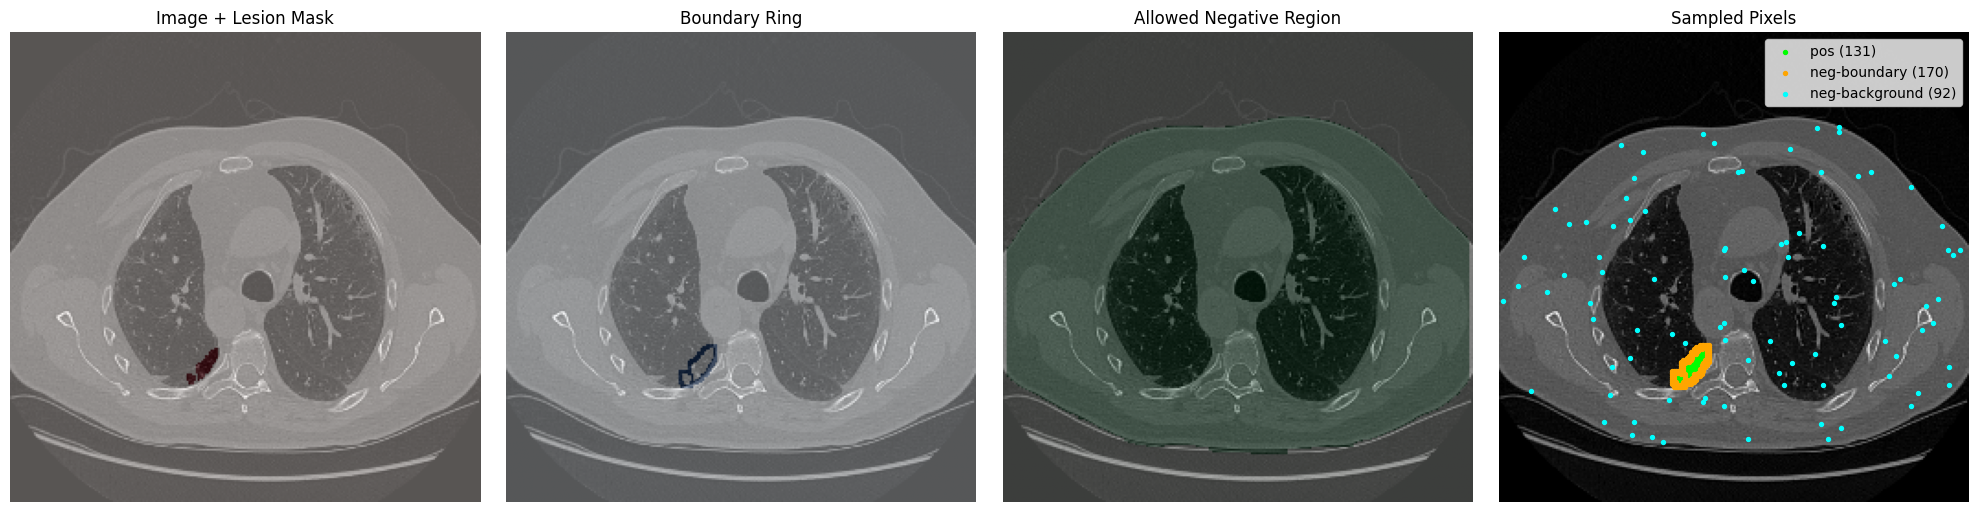

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def _idx_to_yx(indices: torch.Tensor, width: int):
    y = (indices // width).cpu().numpy()
    x = (indices % width).cpu().numpy()
    return y, x

# Grab one batch
images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)

# Use current model to get projected embeddings (only shape is needed for sampling indices)
model.eval()
with torch.no_grad():
    features = model.forward_features(images)
    projected = model.forward_projection(features)

# Pick first image in batch that has tumor pixels
chosen = None
for i in range(masks.shape[0]):
    if (masks[i, 0] > 0.5).any():
        chosen = i
        break
if chosen is None:
    raise RuntimeError("No positive-mask image found in this batch. Try another batch.")

mask_i = masks[chosen:chosen+1]  # (1,1,H,W)
img_i = images[chosen, 0].detach().cpu().numpy()
H, W = mask_i.shape[-2], mask_i.shape[-1]

# Constrain negatives to the anatomy-aware region used during training
neg_sampling_mask_i = compute_negative_sampling_mask(
    images[chosen:chosen+1],
    threshold_ratio=0.10,
    dilation_kernel_size=1,
)[0, 0]

# Recreate sampling indices exactly as in sample_pixel_embeddings
boundary_mask = _compute_boundary_mask(mask_i, kernel_size=boundary_kernel_size)[0, 0]
flat_mask = (mask_i.reshape(-1) > 0.5)
flat_boundary = boundary_mask.reshape(-1)
flat_neg_sampling = neg_sampling_mask_i.reshape(-1)

pos_idx = torch.nonzero(flat_mask, as_tuple=False).squeeze(1)
pos_idx = _sample_indices(pos_idx, max_positive_samples)

target_neg = max_negative_samples
if target_neg is None:
    target_neg = max(1, int(np.ceil(pos_idx.numel() * negative_ratio)))

boundary_candidates = flat_boundary & flat_neg_sampling
boundary_idx = torch.nonzero(boundary_candidates, as_tuple=False).squeeze(1)
if boundary_idx.numel() == 0:
    boundary_idx = torch.nonzero(flat_boundary, as_tuple=False).squeeze(1)

bg_candidates = (~flat_mask) & flat_neg_sampling
bg_idx = torch.nonzero(bg_candidates, as_tuple=False).squeeze(1)
if bg_idx.numel() == 0:
    bg_idx = torch.nonzero(~flat_mask, as_tuple=False).squeeze(1)

max_boundary = min(boundary_idx.numel(), int(np.ceil(target_neg * boundary_fraction)))
neg_boundary_idx = _sample_indices(boundary_idx, max_boundary)

remaining = max(0, target_neg - neg_boundary_idx.numel())
if neg_boundary_idx.numel() > 0:
    keep_bg = ~torch.isin(bg_idx, neg_boundary_idx)
    bg_idx = bg_idx[keep_bg]
neg_bg_idx = _sample_indices(bg_idx, remaining)

# Convert to coordinates
pos_y, pos_x = _idx_to_yx(pos_idx, W)
nb_y, nb_x = _idx_to_yx(neg_boundary_idx, W)
ng_y, ng_x = _idx_to_yx(neg_bg_idx, W)

mask_np = mask_i[0, 0].detach().cpu().numpy()
boundary_np = boundary_mask.detach().cpu().numpy().astype(np.float32)
neg_sampling_np = neg_sampling_mask_i.detach().cpu().numpy().astype(np.float32)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_i, cmap="gray")
axes[0].imshow(mask_np, cmap="Reds", alpha=0.35)
axes[0].set_title("Image + Lesion Mask")
axes[0].axis("off")

axes[1].imshow(img_i, cmap="gray")
axes[1].imshow(boundary_np, cmap="Blues", alpha=0.35)
axes[1].set_title("Boundary Ring")
axes[1].axis("off")

axes[2].imshow(img_i, cmap="gray")
axes[2].imshow(neg_sampling_np, cmap="Greens", alpha=0.25)
axes[2].set_title("Allowed Negative Region")
axes[2].axis("off")

axes[3].imshow(img_i, cmap="gray")
axes[3].scatter(pos_x, pos_y, s=8, c="lime", label=f"pos ({len(pos_x)})")
axes[3].scatter(nb_x, nb_y, s=8, c="orange", label=f"neg-boundary ({len(nb_x)})")
axes[3].scatter(ng_x, ng_y, s=8, c="cyan", label=f"neg-background ({len(ng_x)})")
axes[3].set_title("Sampled Pixels")
axes[3].legend(loc="upper right")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Test-set evaluation (uses the best Phase-2 checkpoint and threshold when available).
eval_criterion = build_phase2_loss(phase2_loss_name)

phase2_best_info = training_artifacts.get('phase2_best', {}) if isinstance(training_artifacts, dict) else {}
ckpt_path = phase2_best_info.get('checkpoint_path', phase2_ckpt if 'phase2_ckpt' in globals() else None)
if ckpt_path is None or not os.path.exists(ckpt_path):
    raise FileNotFoundError(f'Could not find phase-2 checkpoint: {ckpt_path}')

best_threshold = float(phase2_best_info.get('threshold', 0.5))

eval_model = UNetContrastive().to(device)
checkpoint = load_model_checkpoint(eval_model, ckpt_path, strict=True)
if isinstance(checkpoint, dict) and 'threshold' in checkpoint:
    best_threshold = float(checkpoint['threshold'])

eval_model.eval()
test_loss_sum = 0.0
test_prob_batches = []
test_mask_batches = []

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc='Test [Eval]'):
        images = images.to(device)
        masks = masks.to(device)
        features = eval_model.forward_features(images)
        logits = eval_model.forward_classification(features)
        test_loss_sum += float(eval_criterion(logits, masks).item())
        test_prob_batches.append(torch.sigmoid(logits).cpu())
        test_mask_batches.append(masks.cpu())

test_probs = torch.cat(test_prob_batches, dim=0)
test_masks = torch.cat(test_mask_batches, dim=0)

test_probs_np = test_probs.numpy()
test_masks_np = (test_masks.numpy() > 0.5).astype(np.float32)
test_preds_np = (test_probs_np >= best_threshold).astype(np.float32)

test_metrics = {
    'checkpoint_path': ckpt_path,
    'threshold_used': float(best_threshold),
    'test_loss': test_loss_sum / max(1, len(test_loader)),
    'test_global_dice': dice_score_from_binary(test_preds_np, test_masks_np),
    'test_global_iou': iou_score_from_binary(test_preds_np, test_masks_np),
}
roc_diag_test = compute_roc_diagnostics(test_probs, test_masks)
test_metrics['test_roc_auc'] = roc_diag_test['roc_auc']
test_metrics['test_pr_auc'] = roc_diag_test['pr_auc']

print('Test metrics:')
for k, v in test_metrics.items():
    print(f'  {k}: {v}')

test_metrics

Test [Eval]:   0%|          | 0/167 [00:00<?, ?it/s]

Test metrics:
  checkpoint_path: /kaggle/working/contrastive_outputs/checkpoints/contrastive_phase2_best.pth
  threshold_used: 0.1
  test_loss: 0.9829816325695929
  test_global_dice: 0.021725889295339584
  test_global_iou: 0.010982244275510311
  test_roc_auc: 0.6542728862237593
  test_pr_auc: 0.03699775742743937


{'checkpoint_path': '/kaggle/working/contrastive_outputs/checkpoints/contrastive_phase2_best.pth',
 'threshold_used': 0.1,
 'test_loss': 0.9829816325695929,
 'test_global_dice': 0.021725889295339584,
 'test_global_iou': 0.010982244275510311,
 'test_roc_auc': 0.6542728862237593,
 'test_pr_auc': 0.03699775742743937}

In [ ]:
# Dice/IoU on only test images that have GT-positive pixels for the two-phase model.
if 'test_metrics' not in globals():
    raise RuntimeError('test_metrics not found. Run the test evaluation cell first.')

ckpt_path = test_metrics.get('checkpoint_path')
if ckpt_path is None or not os.path.exists(ckpt_path):
    raise FileNotFoundError(f'Checkpoint not found: {ckpt_path}')

threshold = float(test_metrics.get('threshold_used', 0.5))
eval_model = UNetContrastive().to(device)
load_model_checkpoint(eval_model, ckpt_path, strict=True)
eval_model.eval()

per_image_dice = []
per_image_iou = []
gt_positive_count = 0
total_images = 0

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc='GT-positive metrics [Two-Phase]'):
        images = images.to(device)
        masks = masks.to(device)

        features = eval_model.forward_features(images)
        logits = eval_model.forward_classification(features)
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).float()

        preds_np = preds.cpu().numpy().astype(np.float32)
        masks_np = (masks.cpu().numpy() > 0.5).astype(np.float32)

        for i in range(preds_np.shape[0]):
            total_images += 1
            gt_i = masks_np[i, 0]
            if np.sum(gt_i) <= 0.0:
                continue
            pr_i = preds_np[i, 0]
            gt_positive_count += 1
            per_image_dice.append(dice_score_from_binary(pr_i, gt_i))
            per_image_iou.append(iou_score_from_binary(pr_i, gt_i))

if gt_positive_count == 0:
    gt_positive_metrics = {
        'threshold_used': threshold,
        'gt_positive_images': 0,
        'total_test_images': total_images,
        'mean_dice_gt_positive': None,
        'mean_iou_gt_positive': None,
        'std_dice_gt_positive': None,
        'std_iou_gt_positive': None,
        'per_image_dice': [],
        'per_image_iou': [],
    }
else:
    gt_positive_metrics = {
        'threshold_used': threshold,
        'gt_positive_images': gt_positive_count,
        'total_test_images': total_images,
        'mean_dice_gt_positive': float(np.mean(per_image_dice)),
        'mean_iou_gt_positive': float(np.mean(per_image_iou)),
        'std_dice_gt_positive': float(np.std(per_image_dice)),
        'std_iou_gt_positive': float(np.std(per_image_iou)),
        'per_image_dice': per_image_dice,
        'per_image_iou': per_image_iou,
    }

print('\nGT-positive-only metrics (Two-Phase):')
print(f"  gt_positive_images: {gt_positive_metrics['gt_positive_images']} / {gt_positive_metrics['total_test_images']}")
print(f"  threshold_used: {gt_positive_metrics['threshold_used']:.4f}")
print(f"  mean_dice_gt_positive: {gt_positive_metrics['mean_dice_gt_positive']}")
print(f"  mean_iou_gt_positive: {gt_positive_metrics['mean_iou_gt_positive']}")
print(f"  std_dice_gt_positive: {gt_positive_metrics['std_dice_gt_positive']}")
print(f"  std_iou_gt_positive: {gt_positive_metrics['std_iou_gt_positive']}")

gt_positive_metrics

In [ ]:
# Save prediction-vs-ground-truth overlays for the two-phase model.
if 'test_metrics' not in globals():
    raise RuntimeError('test_metrics not found. Run the test evaluation cell first.')

overlay_output_root = os.path.join(output_dir, 'test_overlay_masks_two_phase')
os.makedirs(overlay_output_root, exist_ok=True)
overlay_with_gt_dir = os.path.join(overlay_output_root, 'with_gt')
overlay_without_gt_dir = os.path.join(overlay_output_root, 'without_gt')
os.makedirs(overlay_with_gt_dir, exist_ok=True)
os.makedirs(overlay_without_gt_dir, exist_ok=True)

overlay_ckpt_path = test_metrics.get('checkpoint_path')
if overlay_ckpt_path is None or not os.path.exists(overlay_ckpt_path):
    raise FileNotFoundError(f'Could not find checkpoint for overlay export: {overlay_ckpt_path}')

overlay_model = UNetContrastive().to(device)
load_model_checkpoint(overlay_model, overlay_ckpt_path, strict=True)
overlay_model.eval()

overlay_threshold = float(test_metrics.get('threshold_used', 0.5))
print(f'Using threshold={overlay_threshold:.4f} from {overlay_ckpt_path}')

saved_overlay_count = 0
saved_with_gt_count = 0
saved_without_gt_count = 0

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc='Saving test overlays [Two-Phase]'):
        images = images.to(device)
        masks = masks.to(device)

        features = overlay_model.forward_features(images)
        logits = overlay_model.forward_classification(features)
        probs = torch.sigmoid(logits)
        preds = (probs >= overlay_threshold).float()

        images_np = images.cpu().numpy()
        masks_np = (masks.cpu().numpy() > 0.5).astype(np.float32)
        preds_np = preds.cpu().numpy().astype(np.float32)

        for i in range(images_np.shape[0]):
            img = images_np[i, 0]
            gt = masks_np[i, 0]
            pr = preds_np[i, 0]

            img_min = float(np.min(img))
            img_max = float(np.max(img))
            img_norm = (img - img_min) / (img_max - img_min + 1e-8)

            rgb = np.stack([img_norm, img_norm, img_norm], axis=-1)
            alpha = 0.45

            pred_only = (pr > 0.5) & (gt <= 0.5)
            gt_only = (gt > 0.5) & (pr <= 0.5)
            overlap = (pr > 0.5) & (gt > 0.5)

            rgb[pred_only] = (1.0 - alpha) * rgb[pred_only] + alpha * np.array([1.0, 0.0, 0.0], dtype=np.float32)
            rgb[gt_only] = (1.0 - alpha) * rgb[gt_only] + alpha * np.array([0.0, 1.0, 0.0], dtype=np.float32)
            rgb[overlap] = (1.0 - alpha) * rgb[overlap] + alpha * np.array([1.0, 1.0, 0.0], dtype=np.float32)

            has_gt = bool((gt > 0.5).any())
            target_dir = overlay_with_gt_dir if has_gt else overlay_without_gt_dir
            out_name = f'test_{saved_overlay_count:05d}_overlay.png'
            out_path = os.path.join(target_dir, out_name)
            plt.imsave(out_path, np.clip(rgb, 0.0, 1.0))

            saved_overlay_count += 1
            if has_gt:
                saved_with_gt_count += 1
            else:
                saved_without_gt_count += 1

print(f'Saved {saved_overlay_count} overlay images to: {overlay_output_root}')
print(f'  with_gt: {saved_with_gt_count} -> {overlay_with_gt_dir}')
print(f'  without_gt: {saved_without_gt_count} -> {overlay_without_gt_dir}')

overlay_output_root

Using threshold=0.1000 from /kaggle/working/contrastive_outputs/checkpoints/contrastive_phase2_best.pth


Saving test overlays:   0%|          | 0/167 [00:00<?, ?it/s]

Saved 1335 overlay images to: /kaggle/working/contrastive_outputs/test_overlay_masks
  with_gt: 101 -> /kaggle/working/contrastive_outputs/test_overlay_masks/with_gt
  without_gt: 1234 -> /kaggle/working/contrastive_outputs/test_overlay_masks/without_gt


'/kaggle/working/contrastive_outputs/test_overlay_masks'

In [ ]:
# Create a Kaggle-downloadable zip for saved overlay masks.
import zipfile

overlay_dir_for_zip = overlay_output_root if 'overlay_output_root' in globals() else os.path.join(output_dir, 'test_overlay_masks_two_phase')
if not os.path.isdir(overlay_dir_for_zip):
    raise FileNotFoundError(f'Overlay directory not found: {overlay_dir_for_zip}')

zip_output_path = '/kaggle/working/test_overlay_masks_two_phase.zip'
with zipfile.ZipFile(zip_output_path, mode='w', compression=zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(overlay_dir_for_zip):
        for fname in files:
            src_path = os.path.join(root, fname)
            arcname = os.path.relpath(src_path, overlay_dir_for_zip)
            zf.write(src_path, arcname=arcname)

zip_size_mb = os.path.getsize(zip_output_path) / (1024 * 1024)
print(f'Created zip: {zip_output_path}')
print(f'Zip size: {zip_size_mb:.2f} MB')
zip_output_path

Created zip: /kaggle/working/test_overlay_masks.zip
Zip size: 161.86 MB


'/kaggle/working/test_overlay_masks.zip'

## Training Curves: Loss and Dice
Use this section after training to visualize phase-2 train/validation loss and Dice trends.

In [ ]:
# Plot train/val loss and Dice curves for the two-phase model.
if 'training_artifacts' not in globals():
    raise RuntimeError('training_artifacts not found. Run the two-phase training cell first.')

phase2_history = training_artifacts.get('phase2_history', {})
required = ['train_loss', 'val_loss', 'train_dice', 'val_global_dice']
missing = [k for k in required if k not in phase2_history]
if missing:
    raise KeyError(f'Missing keys in phase2_history: {missing}')

epochs = np.arange(1, len(phase2_history['train_loss']) + 1)
if epochs.size == 0:
    raise RuntimeError('Phase-2 history is empty. Run full two-phase training first.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, phase2_history['train_loss'], marker='o', label='Train Loss')
axes[0].plot(epochs, phase2_history['val_loss'], marker='o', label='Val Loss')
axes[0].set_title('Two-Phase Model (Phase 2) Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, phase2_history['train_dice'], marker='o', label='Train Dice')
axes[1].plot(epochs, phase2_history['val_global_dice'], marker='o', label='Val Dice')
axes[1].set_title('Two-Phase Model (Phase 2) Dice Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()